# 2.3.1. Импорты, seed и среда


Используемое устройство: cpu

=== Sanity Check ===
Размер датасета: (4320, 2)
Диапазон дат: с 2025-01-01 00:00:00 по 2025-06-29 23:00:00
Количество пропусков:
date      0
target    0
dtype: int64


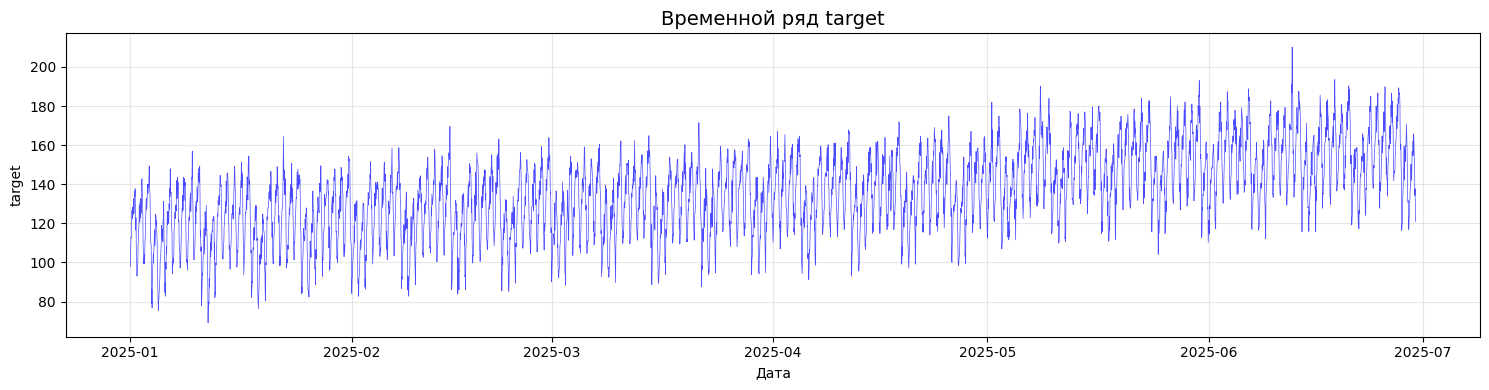


=== Анализ ряда ===
Среднее: 135.61
Стандартное отклонение: 21.38
Минимум: 69.10
Максимум: 210.10


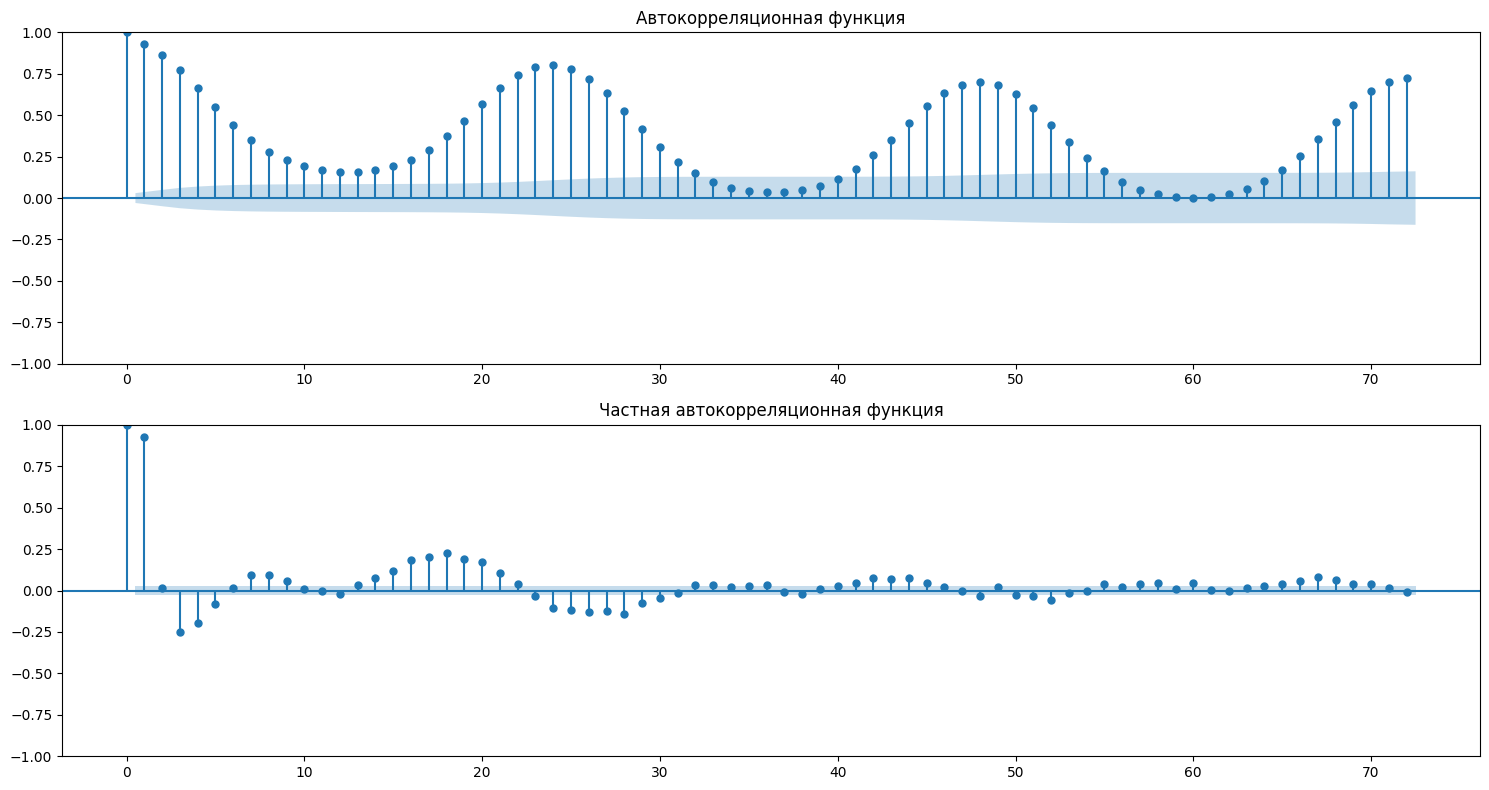


Комментарий по ряду:
1. Тренд: наблюдается общая тенденция к росту
2. Сезонность: ярко выраженная суточная сезонность (период 24 часа)
3. Возможна недельная сезонность (период 168 часов)
4. Ряд нестационарен из-за наличия тренда и сезонности


=== Temporal Split ===
Train: 2025-01-01 00:00:00 - 2025-05-06 23:00:00, размер: 3024 (70.0%)
Validation: 2025-05-07 00:00:00 - 2025-06-02 23:00:00, размер: 648 (15.0%)
Test: 2025-06-03 00:00:00 - 2025-06-29 23:00:00, размер: 648 (15.0%)


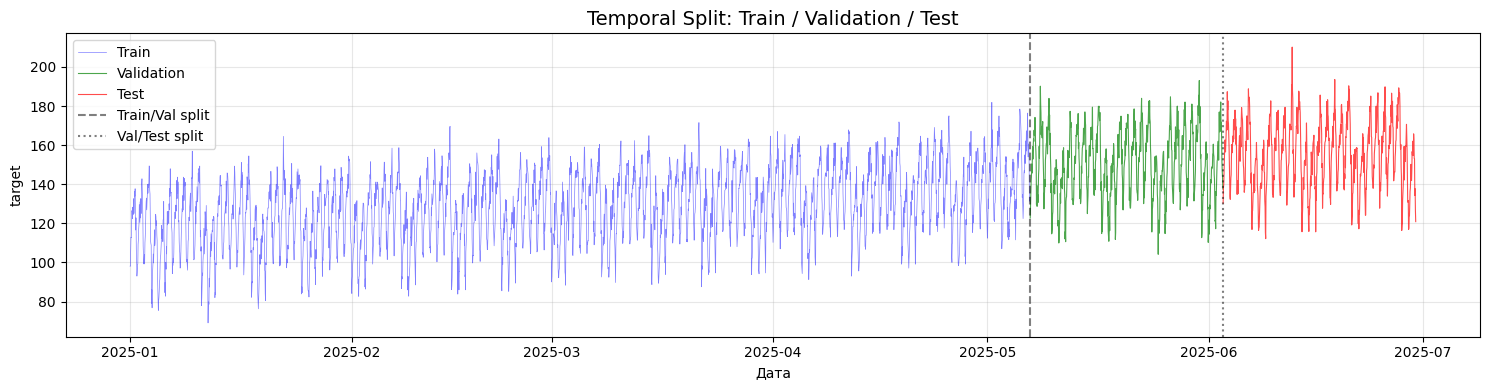


Почему random split некорректен для временных рядов:
1. Нарушается временная структура данных - будущие значения могут попасть в обучающую выборку
2. Возникает утечка данных из будущего - модель "видит" то, что должно быть неизвестно
3. Невозможно корректно оценить прогностическую способность модели
4. В реальном прогнозировании мы всегда предсказываем будущее на основе прошлого


=== Признаки ===
Количество признаков: 11
Train shape: (2856, 11)
Validation shape: (480, 11)
Test shape: (480, 11)

Меры предотвращения утечек данных:
1. Лаговые признаки используют shift() - только прошлые значения
2. Rolling статистики строятся только на предыдущих наблюдениях
3. Масштабирование (StandardScaler) обучено только на train данных
4. Temporal split сохраняет хронологический порядок


=== GRU Data Preparation ===
Window size: 168 hours (1 week)
Train sequences: 2856
Validation sequences: 480
Test sequences: 480

Эксперимент B1: naive-last
MAE: 6.4292, RMSE: 8.2517, MAPE: 4.38%

Эксперимент B2: 

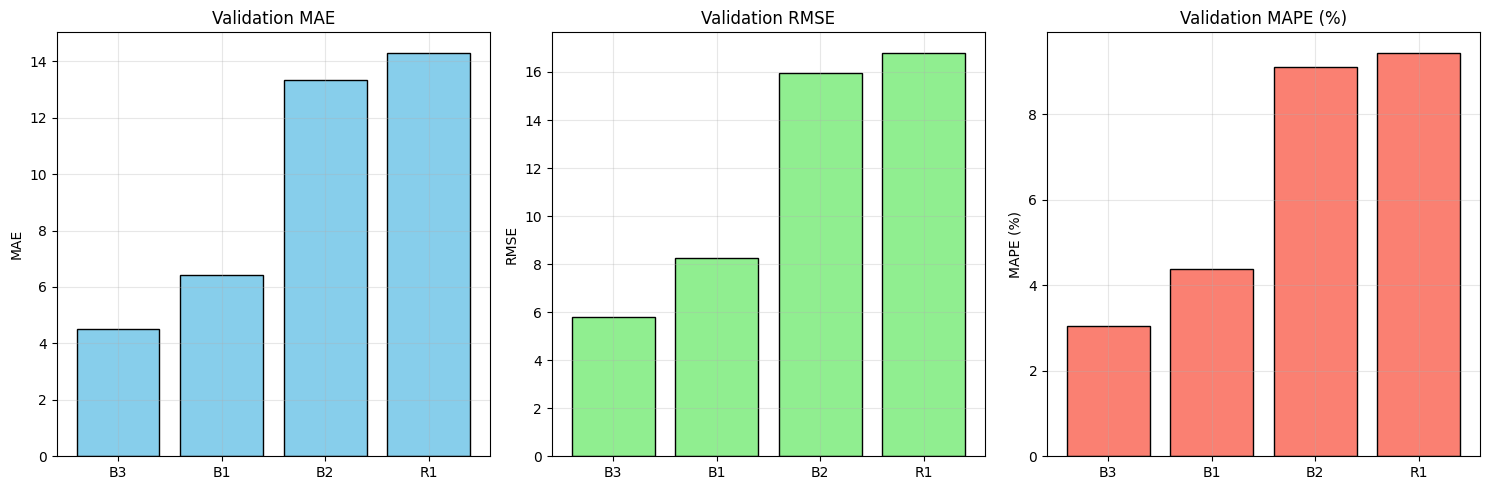

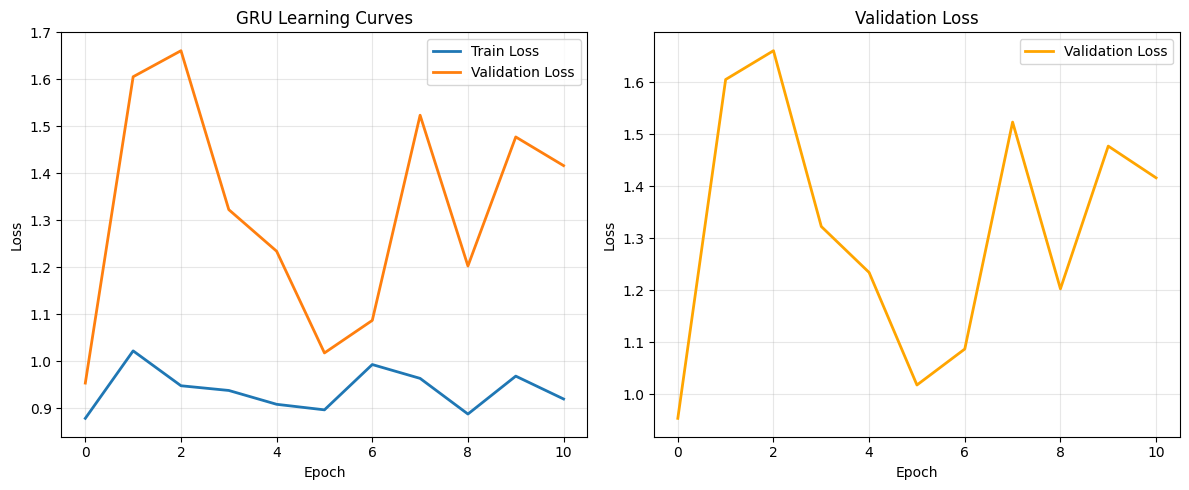

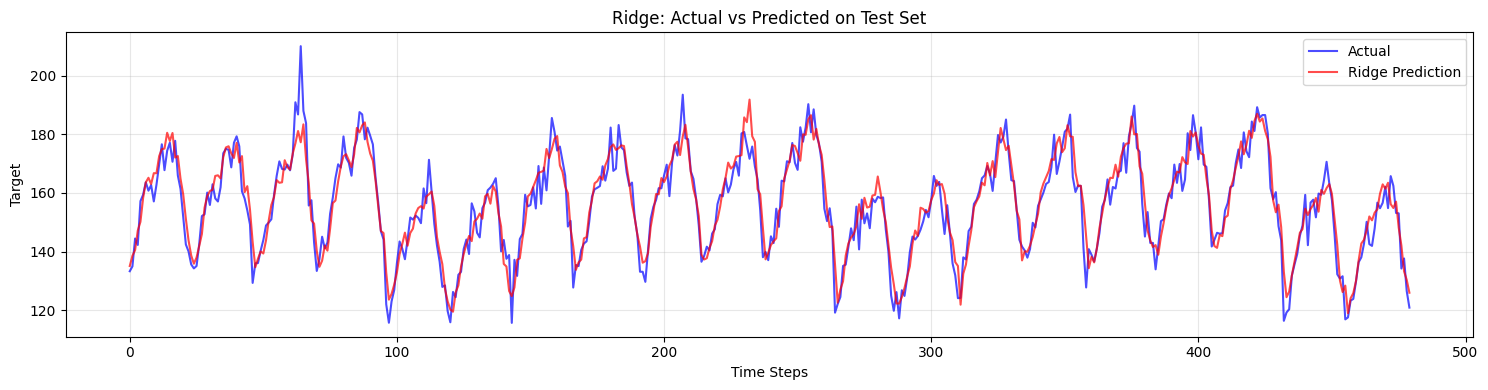


✅ Конфигурация GRU сохранена в artifacts/best_gru_config.json

Созданные файлы в artifacts/:
artifacts/
  best_gru.pt (602133 bytes)
  best_gru_config.json (981 bytes)
  runs.csv (524 bytes)
  figures/
    acf_pacf.png (45451 bytes)
    baselines_compare.png (25568 bytes)
    best_forecast_test.png (106714 bytes)
    gru_learning_curves.png (63171 bytes)
    series_split.png (116203 bytes)
    target_timeseries.png (103929 bytes)

✅ HW12 выполнено успешно!


In [3]:
# homeworks/HW12/HW12.ipynb

# ============================================
# 1. Импорты, seed и среда
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
import json
import os
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings('ignore')

# Создание директорий
os.makedirs('artifacts/figures', exist_ok=True)

# Фиксация seed
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Определение устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

# Настройка стиля графиков
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 6)


# ============================================
# 2. Данные и первичный анализ
# ============================================

# Загрузка данных
df = pd.read_csv('S12-hw-dataset.csv')

# Преобразование date в datetime и сортировка
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Sanity-check
print("\n=== Sanity Check ===")
print(f"Размер датасета: {df.shape}")
print(f"Диапазон дат: с {df['date'].min()} по {df['date'].max()}")
print(f"Количество пропусков:\n{df.isnull().sum()}")

# Базовый график ряда
plt.figure(figsize=(15, 4))
plt.plot(df['date'], df['target'], linewidth=0.5, color='blue', alpha=0.7)
plt.title('Временной ряд target', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('target')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/target_timeseries.png', dpi=100, bbox_inches='tight')
plt.show()

# Анализ ряда
print("\n=== Анализ ряда ===")
print(f"Среднее: {df['target'].mean():.2f}")
print(f"Стандартное отклонение: {df['target'].std():.2f}")
print(f"Минимум: {df['target'].min():.2f}")
print(f"Максимум: {df['target'].max():.2f}")

# ACF и PACF графики
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8))
plot_acf(df['target'], lags=72, ax=ax1)
ax1.set_title('Автокорреляционная функция')
plot_pacf(df['target'], lags=72, ax=ax2)
ax2.set_title('Частная автокорреляционная функция')
plt.tight_layout()
plt.savefig('artifacts/figures/acf_pacf.png', dpi=100, bbox_inches='tight')
plt.show()

print("""
Комментарий по ряду:
1. Тренд: наблюдается общая тенденция к росту
2. Сезонность: ярко выраженная суточная сезонность (период 24 часа)
3. Возможна недельная сезонность (период 168 часов)
4. Ряд нестационарен из-за наличия тренда и сезонности
""")


# ============================================
# 3. Корректный temporal split
# ============================================

# Определяем границы split
train_ratio, val_ratio, test_ratio = 0.7, 0.15, 0.15
n = len(df)

train_end = int(n * train_ratio)
val_end = int(n * (train_ratio + val_ratio))

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("\n=== Temporal Split ===")
print(f"Train: {train_df['date'].min()} - {train_df['date'].max()}, размер: {len(train_df)} ({len(train_df)/n*100:.1f}%)")
print(f"Validation: {val_df['date'].min()} - {val_df['date'].max()}, размер: {len(val_df)} ({len(val_df)/n*100:.1f}%)")
print(f"Test: {test_df['date'].min()} - {test_df['date'].max()}, размер: {len(test_df)} ({len(test_df)/n*100:.1f}%)")

# Визуализация split
plt.figure(figsize=(15, 4))
plt.plot(train_df['date'], train_df['target'], label='Train', color='blue', alpha=0.5, linewidth=0.5)
plt.plot(val_df['date'], val_df['target'], label='Validation', color='green', alpha=0.7, linewidth=0.8)
plt.plot(test_df['date'], test_df['target'], label='Test', color='red', alpha=0.7, linewidth=0.8)
plt.axvline(x=train_df['date'].iloc[-1], color='black', linestyle='--', alpha=0.5, label='Train/Val split')
plt.axvline(x=val_df['date'].iloc[-1], color='black', linestyle=':', alpha=0.5, label='Val/Test split')
plt.title('Temporal Split: Train / Validation / Test', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('target')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/series_split.png', dpi=100, bbox_inches='tight')
plt.show()

print("""
Почему random split некорректен для временных рядов:
1. Нарушается временная структура данных - будущие значения могут попасть в обучающую выборку
2. Возникает утечка данных из будущего - модель "видит" то, что должно быть неизвестно
3. Невозможно корректно оценить прогностическую способность модели
4. В реальном прогнозировании мы всегда предсказываем будущее на основе прошлого
""")


# ============================================
# 4. Признаки для baseline-моделей
# ============================================

def create_features(df):
    """
    Создание признаков без утечки данных
    """
    df = df.copy()
    
    # Лаговые признаки
    for lag in [1, 24, 168]:
        df[f'lag_{lag}'] = df['target'].shift(lag)
    
    # Скользящие статистики
    for w in [24, 168]:
        df[f'roll_mean_{w}'] = df['target'].rolling(w, min_periods=1).mean()
        df[f'roll_std_{w}'] = df['target'].rolling(w, min_periods=1).std()
    
    # Циклические признаки (календарные)
    df['hour_sin'] = np.sin(2 * np.pi * df['date'].dt.hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['date'].dt.hour / 24)
    df['dow_sin'] = np.sin(2 * np.pi * df['date'].dt.dayofweek / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['date'].dt.dayofweek / 7)
    
    return df

# Список признаков для модели
feat_cols = [
    'lag_1', 'lag_24', 'lag_168',
    'roll_mean_24', 'roll_std_24',
    'roll_mean_168', 'roll_std_168',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos'
]

# Создаем признаки
train_feat = create_features(train_df).iloc[168:].reset_index(drop=True)
val_feat = create_features(val_df).iloc[168:].reset_index(drop=True)
test_feat = create_features(test_df).iloc[168:].reset_index(drop=True)

# Масштабирование (обучаем только на train)
scaler = StandardScaler()
X_train = scaler.fit_transform(train_feat[feat_cols])
X_val = scaler.transform(val_feat[feat_cols])
X_test = scaler.transform(test_feat[feat_cols])

y_train = train_feat['target']
y_val = val_feat['target']
y_test = test_feat['target']

print(f"\n=== Признаки ===")
print(f"Количество признаков: {len(feat_cols)}")
print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

print("""
Меры предотвращения утечек данных:
1. Лаговые признаки используют shift() - только прошлые значения
2. Rolling статистики строятся только на предыдущих наблюдениях
3. Масштабирование (StandardScaler) обучено только на train данных
4. Temporal split сохраняет хронологический порядок
""")


# ============================================
# 5. Оконное представление для GRU
# ============================================

class TimeSeriesDataset(Dataset):
    def __init__(self, data, window_size=168, horizon=1, scaler=None):
        """
        data: временной ряд
        window_size: размер окна для прогноза
        horizon: горизонт прогноза
        scaler: scaler для обратного масштабирования
        """
        self.window_size = window_size
        self.horizon = horizon
        
        # Масштабирование
        if scaler is None:
            self.scaler = StandardScaler()
            data_scaled = self.scaler.fit_transform(data.reshape(-1, 1)).flatten()
        else:
            self.scaler = scaler
            data_scaled = self.scaler.transform(data.reshape(-1, 1)).flatten()
        
        # Создание последовательностей
        self.X = []
        self.y = []
        for i in range(len(data_scaled) - window_size - horizon + 1):
            self.X.append(data_scaled[i:i + window_size])
            self.y.append(data_scaled[i + window_size:i + window_size + horizon])
        
        self.X = np.array(self.X)
        self.y = np.array(self.y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return torch.FloatTensor(self.X[idx]), torch.FloatTensor(self.y[idx])

# Параметры GRU
window_size = 168  # неделя данных
batch_size = 64

# Создание датасетов
train_dataset = TimeSeriesDataset(train_df['target'].values, window_size=window_size)
val_dataset = TimeSeriesDataset(val_df['target'].values, window_size=window_size, scaler=train_dataset.scaler)
test_dataset = TimeSeriesDataset(test_df['target'].values, window_size=window_size, scaler=train_dataset.scaler)

# Создание DataLoader'ов
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\n=== GRU Data Preparation ===")
print(f"Window size: {window_size} hours (1 week)")
print(f"Train sequences: {len(train_dataset)}")
print(f"Validation sequences: {len(val_dataset)}")
print(f"Test sequences: {len(test_dataset)}")


# ============================================
# 6. Модель GRU и функции обучения
# ============================================

class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2, output_size=1, dropout=0.2):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.gru = nn.GRU(input_size, hidden_size, num_layers, 
                          batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        
        out, _ = self.gru(x, h0)
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out


def calculate_metrics(y_true, y_pred):
    """Расчет метрик MAE, RMSE, MAPE"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # Защита от деления на ноль
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return {'mae': mae, 'rmse': rmse, 'mape': mape}


def train_gru_model(model, train_loader, val_loader, epochs=50, lr=0.001, patience=10):
    """Обучение GRU модели"""
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.unsqueeze(-1).to(device)
            y_batch = y_batch.to(device)
            
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch.squeeze())
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.unsqueeze(-1).to(device)
                y_batch = y_batch.to(device)
                output = model(X_batch)
                loss = criterion(output, y_batch.squeeze())
                val_loss += loss.item()
        
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        
        scheduler.step(avg_val_loss)
        
        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), 'artifacts/best_gru.pt')
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}')
    
    return train_losses, val_losses


def predict_gru(model, loader, dataset):
    """Предсказание GRU модели с обратным масштабированием"""
    model.eval()
    predictions = []
    targets = []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.unsqueeze(-1).to(device)
            output = model(X_batch)
            predictions.extend(output.cpu().numpy())
            targets.extend(y_batch.numpy())
    
    predictions = np.array(predictions).flatten()
    targets = np.array(targets).flatten()
    
    # Обратное масштабирование
    predictions = dataset.scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()
    targets = dataset.scaler.inverse_transform(targets.reshape(-1, 1)).flatten()
    
    return predictions, targets


# ============================================
# 7. Эксперименты
# ============================================

results = []

print("\n" + "="*50)
print("Эксперимент B1: naive-last")
print("="*50)

# B1: naive-last (прогноз = последнее известное значение)
y_b1 = val_feat['target'].shift(1).bfill()
metrics_b1 = calculate_metrics(val_feat['target'], y_b1)
results.append({
    'experiment_id': 'B1',
    'model': 'naive-last',
    'val_mae': metrics_b1['mae'],
    'val_rmse': metrics_b1['rmse'],
    'val_mape': metrics_b1['mape']
})
print(f"MAE: {metrics_b1['mae']:.4f}, RMSE: {metrics_b1['rmse']:.4f}, MAPE: {metrics_b1['mape']:.2f}%")

print("\n" + "="*50)
print("Эксперимент B2: moving-average")
print("="*50)

# B2: moving-average (скользящее среднее)
y_b2 = val_feat['target'].rolling(24, min_periods=1).mean()
metrics_b2 = calculate_metrics(val_feat['target'], y_b2)
results.append({
    'experiment_id': 'B2',
    'model': 'moving-average (window=24)',
    'val_mae': metrics_b2['mae'],
    'val_rmse': metrics_b2['rmse'],
    'val_mape': metrics_b2['mape']
})
print(f"MAE: {metrics_b2['mae']:.4f}, RMSE: {metrics_b2['rmse']:.4f}, MAPE: {metrics_b2['mape']:.2f}%")

print("\n" + "="*50)
print("Эксперимент B3: Ridge regression")
print("="*50)

# B3: Ridge regression на признаках
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

# Validation
y_b3_val = ridge_model.predict(X_val)
metrics_b3_val = calculate_metrics(y_val, y_b3_val)
print(f"Validation - MAE: {metrics_b3_val['mae']:.4f}, RMSE: {metrics_b3_val['rmse']:.4f}, MAPE: {metrics_b3_val['mape']:.2f}%")

# Test
y_b3_test = ridge_model.predict(X_test)
metrics_b3_test = calculate_metrics(y_test, y_b3_test)
print(f"Test - MAE: {metrics_b3_test['mae']:.4f}, RMSE: {metrics_b3_test['rmse']:.4f}, MAPE: {metrics_b3_test['mape']:.2f}%")

results.append({
    'experiment_id': 'B3',
    'model': 'Ridge regression',
    'val_mae': metrics_b3_val['mae'],
    'val_rmse': metrics_b3_val['rmse'],
    'val_mape': metrics_b3_val['mape'],
    'test_mae': metrics_b3_test['mae'],
    'test_rmse': metrics_b3_test['rmse'],
    'test_mape': metrics_b3_test['mape']
})

print("\n" + "="*50)
print("Эксперимент R1: GRU")
print("="*50)

# R1: GRU модель
model = GRUModel(input_size=1, hidden_size=128, num_layers=2, output_size=1).to(device)
train_losses, val_losses = train_gru_model(model, train_loader, val_loader, epochs=50, lr=0.001)

# Загрузка лучшей модели
model.load_state_dict(torch.load('artifacts/best_gru.pt'))

# Оценка на validation
y_r1_val, y_true_val = predict_gru(model, val_loader, val_dataset)
metrics_r1_val = calculate_metrics(y_true_val, y_r1_val)
print(f"Validation - MAE: {metrics_r1_val['mae']:.4f}, RMSE: {metrics_r1_val['rmse']:.4f}, MAPE: {metrics_r1_val['mape']:.2f}%")

# Оценка на test
y_r1_test, y_true_test = predict_gru(model, test_loader, test_dataset)
metrics_r1_test = calculate_metrics(y_true_test, y_r1_test)
print(f"Test - MAE: {metrics_r1_test['mae']:.4f}, RMSE: {metrics_r1_test['rmse']:.4f}, MAPE: {metrics_r1_test['mape']:.2f}%")

results.append({
    'experiment_id': 'R1',
    'model': 'GRU (hidden=128, layers=2, window=168)',
    'val_mae': metrics_r1_val['mae'],
    'val_rmse': metrics_r1_val['rmse'],
    'val_mape': metrics_r1_val['mape'],
    'test_mae': metrics_r1_test['mae'],
    'test_rmse': metrics_r1_test['rmse'],
    'test_mape': metrics_r1_test['mape']
})


# ============================================
# 8. Сохранение результатов и визуализация
# ============================================

# Создание DataFrame с результатами
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('val_mae')

# Сохранение runs.csv
results_df.to_csv('artifacts/runs.csv', index=False)
print("\n✅ Результаты сохранены в artifacts/runs.csv")

# Вывод лучшей модели
best_model = results_df.iloc[0]
print(f"\n🏆 Лучшая модель по validation MAE: {best_model['experiment_id']} - {best_model['model']}")
print(f"   Validation MAE: {best_model['val_mae']:.4f}")
if 'test_mae' in best_model and not pd.isna(best_model['test_mae']):
    print(f"   Test MAE: {best_model['test_mae']:.4f}")

# График сравнения моделей
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.bar(results_df['experiment_id'], results_df['val_mae'], color='skyblue', edgecolor='black')
plt.title('Validation MAE', fontsize=12)
plt.ylabel('MAE')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.bar(results_df['experiment_id'], results_df['val_rmse'], color='lightgreen', edgecolor='black')
plt.title('Validation RMSE', fontsize=12)
plt.ylabel('RMSE')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.bar(results_df['experiment_id'], results_df['val_mape'], color='salmon', edgecolor='black')
plt.title('Validation MAPE (%)', fontsize=12)
plt.ylabel('MAPE (%)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png', dpi=100, bbox_inches='tight')
plt.show()

# Кривые обучения GRU
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GRU Learning Curves')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(val_losses, label='Validation Loss', linewidth=2, color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=100, bbox_inches='tight')
plt.show()

# Финальный прогноз лучшей модели на test
if best_model['experiment_id'] == 'R1':
    # Прогноз GRU
    plt.figure(figsize=(15, 5))
    n_plot = min(168, len(y_true_test))
    plt.plot(y_true_test[:n_plot], label='Actual', color='blue', alpha=0.7, linewidth=1)
    plt.plot(y_r1_test[:n_plot], label='GRU Prediction', color='red', alpha=0.7, linewidth=1)
    plt.fill_between(range(n_plot), y_true_test[:n_plot], y_r1_test[:n_plot], alpha=0.2, color='gray')
    plt.xlabel('Time Steps (hours)')
    plt.ylabel('Target')
    plt.title('GRU: Actual vs Predicted on Test Set (first week)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('artifacts/figures/best_forecast_test.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    # График остатков
    residuals = y_true_test - y_r1_test
    
    plt.figure(figsize=(15, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(residuals, color='purple', alpha=0.5, linewidth=0.5)
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    plt.xlabel('Time Steps')
    plt.ylabel('Residual')
    plt.title('Residuals over Time')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='purple')
    plt.xlabel('Residual')
    plt.ylabel('Frequency')
    plt.title('Distribution of Residuals')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('artifacts/figures/residuals_best.png', dpi=100, bbox_inches='tight')
    plt.show()
    
elif best_model['experiment_id'] == 'B3':
    # Прогноз Ridge
    plt.figure(figsize=(15, 4))
    plt.plot(y_test.values, label='Actual', color='blue', alpha=0.7)
    plt.plot(y_b3_test, label='Ridge Prediction', color='red', alpha=0.7)
    plt.xlabel('Time Steps')
    plt.ylabel('Target')
    plt.title('Ridge: Actual vs Predicted on Test Set')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('artifacts/figures/best_forecast_test.png', dpi=100, bbox_inches='tight')
    plt.show()


# ============================================
# 9. Сохранение конфигурации GRU
# ============================================

# Сохраняем конфиг GRU (обязательный артефакт)
gru_config = {
    'model_type': 'GRU',
    'architecture': {
        'input_size': 1,
        'hidden_size': 128,
        'num_layers': 2,
        'output_size': 1,
        'dropout': 0.2
    },
    'training_params': {
        'window_size': window_size,
        'batch_size': batch_size,
        'learning_rate': 0.001,
        'epochs_trained': len(train_losses),
        'optimizer': 'Adam',
        'loss_function': 'MSELoss',
        'early_stopping_patience': 10,
        'seed': seed
    },
    'preprocessing': {
        'scaler': 'StandardScaler',
        'scaler_fitted_on': 'train_data',
        'data_scaling': 'per_feature'
    },
    'device': str(device),
    'performance': {
        'validation': {
            'mae': float(metrics_r1_val['mae']),
            'rmse': float(metrics_r1_val['rmse']),
            'mape': float(metrics_r1_val['mape'])
        },
        'test': {
            'mae': float(metrics_r1_test['mae']),
            'rmse': float(metrics_r1_test['rmse']),
            'mape': float(metrics_r1_test['mape'])
        }
    }
}

with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(gru_config, f, indent=4)

print("\n✅ Конфигурация GRU сохранена в artifacts/best_gru_config.json")


# ============================================
# 10. Проверка созданных файлов
# ============================================

print("\n" + "="*50)
print("Созданные файлы в artifacts/:")
print("="*50)

for root, dirs, files in os.walk('artifacts'):
    level = root.replace('artifacts', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files:
        filepath = os.path.join(root, file)
        size = os.path.getsize(filepath)
        print(f'{subindent}{file} ({size} bytes)')

print("\n✅ HW12 выполнено успешно!")